In [1]:
import argparse
import at
from pySC import disable_pySC_rich
from pySC.configuration.generation import generate_SC
from pySC.tuning.response_measurements import measure_OrbitResponseMatrix
from pySC.tuning.response_measurements import measure_RFFrequencyOrbitResponse
from pySC.tuning.averaging import get_average_orbit

from run_pyloco_from_model import run_pyloco_from_model
from set_correction import last_by_sorted_key, get_quads_block, set_correction
import os
import h5py
from analyze_ring import analyze_ring
import matplotlib.pyplot as plt
import numpy as np
disable_pySC_rich()
scale_errors = 1
seed = 1
yaml_filepath = 'ebs_conf_betamodel.yaml'
SC = generate_SC(yaml_filepath, seed=1, scale_errors=scale_errors, sigma_truncate=3)
QD3 =at.get_refpts(SC.lattice.design, 'QD3[AE]*')
QF4 =at.get_refpts(SC.lattice.design, 'QF4[ABDE]*')
QD5 =at.get_refpts(SC.lattice.design, 'QD5[BD]*')
combined = np.concatenate((QD3, QF4, QD5))
quad_indices = np.sort(combined)
used_bpms_ords = at.get_refpts(SC.lattice.design, at.elements.Monitor)

Scaling error_table by 1
05 Nov 2025, 11:32:40 | INFO | Loading AT lattice from betamodel.mat


/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


05 Nov 2025, 11:32:43 | INFO | Configuring magnets...
05 Nov 2025, 11:32:43 | INFO | Found 632 (DL) matching regex '^DL', excluding regex '.*_MARKER'
05 Nov 2025, 11:32:44 | INFO | Found 99 (DQ) matching regex '^DQ', excluding regex '.*_MARKER'
05 Nov 2025, 11:32:44 | INFO | Found 514 (quadrupoles) matching regex '^QD|^QF'
05 Nov 2025, 11:32:44 | INFO | Found 192 (sextupoles) matching regex '^SJ|^SF|^SD|^SI'
05 Nov 2025, 11:32:44 | INFO | Found 64 (octupoles) matching regex '^O'
05 Nov 2025, 11:32:44 | INFO | Found 96 (correctors) matching regex '^SH'
05 Nov 2025, 11:32:44 | INFO | Configuring BPMs...
05 Nov 2025, 11:32:44 | INFO | Found 320 (bpms) matching regex '^BPM', excluding regex 'BPM_TFB|BPM_LFB|BPM_CUR'
05 Nov 2025, 11:32:44 | INFO | Configuring rf...
05 Nov 2025, 11:32:44 | INFO | Found 13 (main) matching regex '^CAV'
05 Nov 2025, 11:32:44 | INFO | Configuring supports...
05 Nov 2025, 11:32:44 | INFO | Resolving supports: looping through L0
05 Nov 2025, 11:32:44 | INFO | Conf

In [2]:
elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.7919 µm
RMS vertical orbit           :   0.0098 µm
RMS horizontal beta beating  :   0.0000 %
RMS vertical beta beating    :   0.0000 %
RMS horizontal dispersion err:   0.0000 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Chromaticity                 : [7.38452899e+00 7.54957156e+00 4.92570068e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 140.83913009532876 emittance_v 0.0
----------------------------------------------------------------------


In [3]:
# Apply error to one quad
SC.lattice.ring[quad_indices[0]].K += 55e-3
SC.lattice.ring[quad_indices[100]].K += 55e-3

elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.8446 µm
RMS vertical orbit           :   0.0096 µm
RMS horizontal beta beating  :   9.0670 %
RMS vertical beta beating    :   2.9443 %
RMS horizontal dispersion err:   9.4019 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61803686e+01 2.73287176e+01 3.67747916e-03]
Chromaticity                 : [7.63379613e+00 7.45976395e+00 4.86818741e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 171.80072148078483 emittance_v 0.0
----------------------------------------------------------------------


In [4]:
# pyLOCO

# ORM, dispersion and BPM noise measurements

HCORR = SC.tuning.HCORR
VCORR = SC.tuning.VCORR
orm = measure_OrbitResponseMatrix(SC, HCORR, VCORR, dkick = 100e-6, normalize=False, bipolar=True) #[BPMS x cor] in meter
eta =  measure_RFFrequencyOrbitResponse(SC, delta_frf =200, normalize = False, bipolar=True)
etax = eta[:len(eta)//2] # meter
etay = eta[len(eta)//2:] # meter
x, y, x_std, y_std = get_average_orbit(SC, 100)
sigma_w = np.concatenate((x_std, y_std))  # meter

# save measurements in proper unit and format
os.makedirs("./data", exist_ok=True)

with h5py.File("./data/measured_orm_loco.h5", "w") as f:
    f.create_dataset("response_matrix", data=orm)

with h5py.File("./data/measured_dispersion_loco.h5", "w") as f:
    f.create_dataset("measured_eta_x", data=etax)
    f.create_dataset("measured_eta_y", data=etay)
    f.attrs["delta_frf"] = 200

#x_std = np.ones_like(used_bpms_ords)
#y_std = np.ones_like(used_bpms_ords)
#sigma_w = np.concatenate((x_std, y_std))

with h5py.File("./data/measured_BPM_noise_loco.h5", "w") as f:
    f.create_dataset("Noise_BPMx", data=x_std)
    f.create_dataset("Noise_BPMy", data=y_std)

Calculating response matrix


/Users/elafmusa/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Plot saved to: data/orms_comparison.png


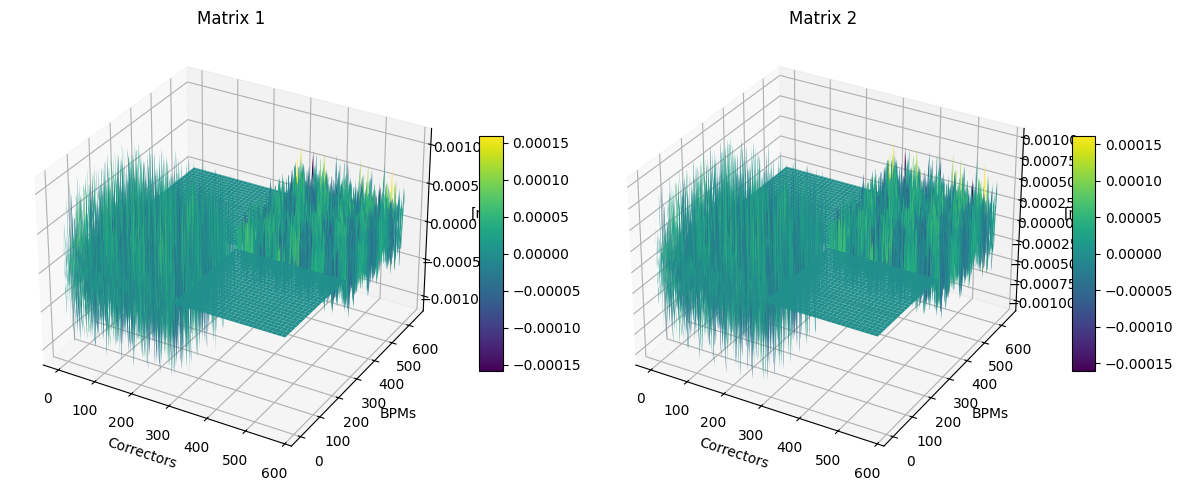

RMS difference between model and measured ORM: 3.042e-05 m


In [5]:
from pyLOCO.pyloco import remove_bad_bpms, plot_matrices
from pyLOCO.response_matrix import response_matrix
from pyloco_config import FitInitConfig, RMConfig, fixed_parameters
ring = at.load_lattice('betamodel.mat', use='betamodel')
ring.disable_6d()

cor_indices = at.get_refpts(ring, 'S[HFDIJ]*')
Corords = [cor_indices, cor_indices]

CMstep = [[100e-6] * len(Corords[0]), [100e-6] * len(Corords[1])]


fit_cfg = FitInitConfig()
includeDispersion = False
HCMCoupling = np.zeros(len(Corords[0]))
VCMCoupling = np.zeros(len(Corords[1]))

cfg = RMConfig(
    dkick=CMstep,
    bpm_ords=used_bpms_ords,
    cm_ords=Corords,
    HCMCoupling=HCMCoupling,
    VCMCoupling=VCMCoupling,
    rfStep=fixed_parameters.rfstep,
    includeDispersion=includeDispersion
)

# --- Compute model ORM ---

orm_model = response_matrix(ring, config=cfg)

rms_diff = np.sqrt(np.mean((orm_model - orm)**2))
os.makedirs("data", exist_ok=True)
plot_matrices(orm_model, orm, titles=None, cmap='viridis', plot_type='3d', save_path="data/orms_comparison.png")

print(f"RMS difference between model and measured ORM: {rms_diff:.3e} m")

Before_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.8449 µm
RMS vertical orbit           :   0.0101 µm
RMS horizontal beta beating  :   9.0670 %
RMS vertical beta beating    :   2.9443 %
RMS horizontal dispersion err:   9.4019 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61803686e+01 2.73287176e+01 3.67747916e-03]
Chromaticity                 : [7.63379613e+00 7.45976395e+00 4.86818741e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 171.80072148078483 emittance_v 0.0
----------------------------------------------------------------------

==== Iteration 1/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/

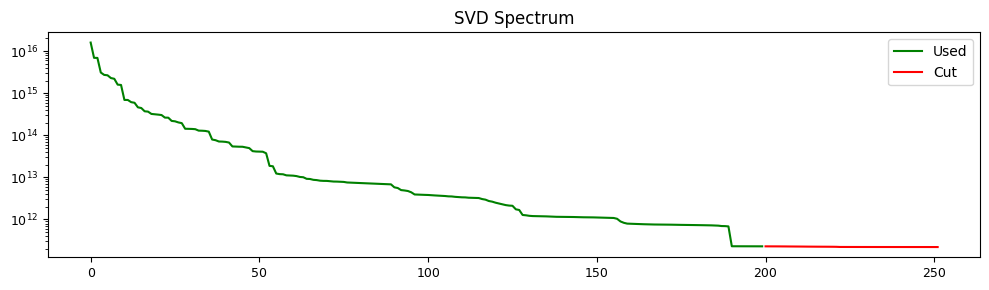

  LM inner 1: chi² 6.1888e+05 (previous 1.9433e+07), λ=0.001
Chi² after correction: 6.1888e+05

==== Iteration 2/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 6.1888e+05


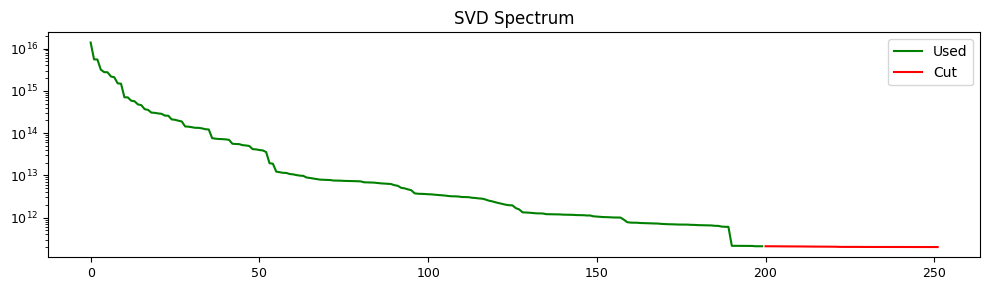

  LM inner 1: chi² 7.8395e+04 (previous 6.1888e+05), λ=0.001
Chi² after correction: 7.8395e+04

==== Iteration 3/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 7.8395e+04


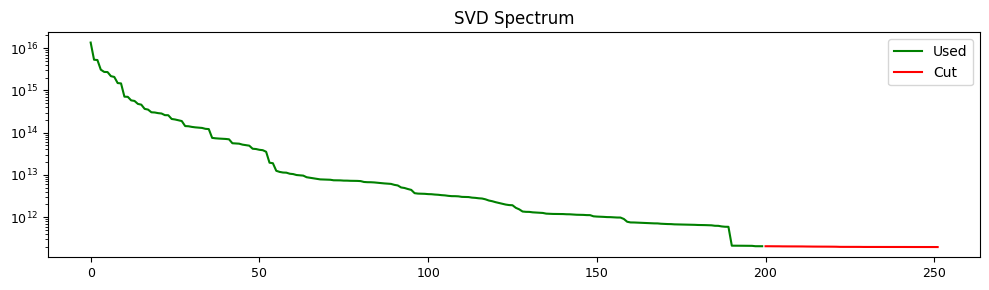

  LM inner 1: chi² 7.7504e+04 (previous 7.8395e+04), λ=0.001
Chi² after correction: 7.7504e+04

==== Iteration 4/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 7.7504e+04


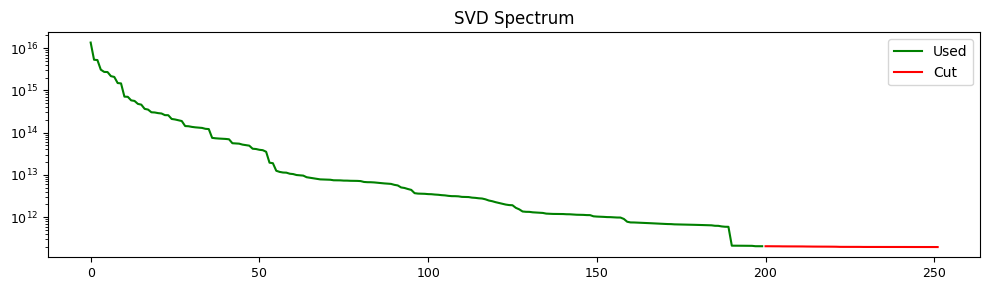

  LM inner 1: chi² 7.7469e+04 (previous 7.7504e+04), λ=0.001
Chi² after correction: 7.7469e+04

==== Iteration 5/5 – LM ====
[calculate_quads_jacobian] Logs saved to '/Users/elafmusa/Desktop/pyLOCO/Examples/reconstruct_quadrupoles_errors/output/quad_jacobian_logs.txt'
Initial Chi²: 7.7469e+04


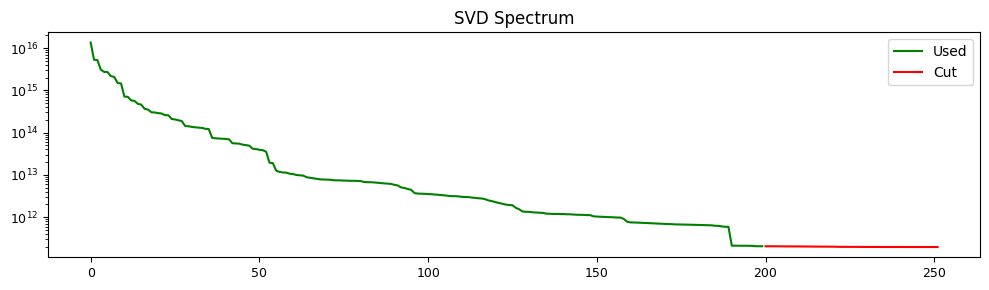

  LM inner 1: chi² 7.7443e+04 (previous 7.7469e+04), λ=0.001
Chi² after correction: 7.7443e+04
LOCO LM completed! :).


In [6]:
from analyze_ring import analyze_ring

print('Before_pyLOCO_iteration')
elements_ind = at.get_refpts(SC.lattice.design, '*')
analyze_ring(SC, elements_ind, useIdealRing=False, makeplot=False)

# run pyloco
#orm = np.hstack((orm, eta.reshape(-1, 1))) #When include_dispersion is true in the config
config_path =  os.path.abspath("pyloco_config.py")
current_fit_parameters, fit_parameters_dic, ring_pyloco = run_pyloco_from_model(
                        orm, sigma_w,  etax,  etay,  config_path=config_path
                    )

In [7]:
# apply correction

inner = last_by_sorted_key(fit_parameters_dic)
quads_fit, skew_fit = get_quads_block(inner)
delta_q = np.asarray(
[quads_fit[i] - SC.lattice.design[quad_indices[i]].K for i in range(len(quad_indices))],
dtype = float
).ravel()

#delta_skew = np.asarray(
#[skew_fit[i] - SC.lattice.design[skew_ord[i]].K for i in range(len(skew_ord))],
#dtype = float
#).ravel()



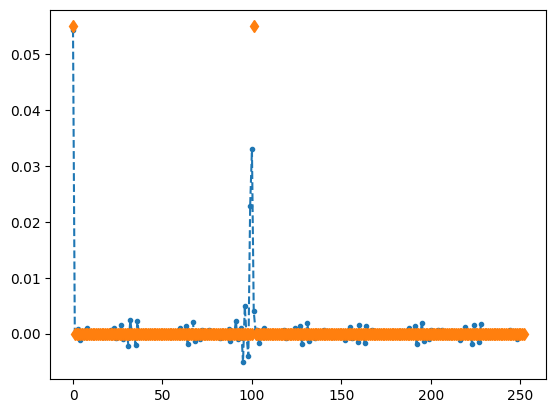

In [8]:
len(quad_indices)
measurment_err = []

for i in quad_indices:
    if i == quad_indices[0]:
        measurment_err.append(55e-3)

    if i == quad_indices[100]:
        measurment_err.append(55e-3)

    else:
        measurment_err.append(0)
loco_fit = delta_q
plt.plot(loco_fit,'.--')
plt.plot(measurment_err,'d')

In [9]:
set_correction(SC, -delta_q, quad_indices, individuals=True, skewness=False)
#set_correction(SC, -delta_skew, skew_ord, individuals=True, skewness=True)
print('After_pyLOCO_iteration')
_, _, twiss0 = at.get_optics(SC.lattice.design, elements_ind)
analyze_ring(SC, twiss0, elements_ind, useIdealRing=False, makeplot=False)

After_pyLOCO_iteration
----------------------- Analyzing the Lattice ------------------------
RMS horizontal orbit         :   3.8446 µm
RMS vertical orbit           :   0.0096 µm
RMS horizontal beta beating  :  11.6504 %
RMS vertical beta beating    :   2.9948 %
RMS horizontal dispersion err:  13.0420 mm
RMS vertical dispersion err  :   0.0000 mm
Ideal Tune                         : [7.61599761e+01 2.73400179e+01 3.68122768e-03]
Ideal Chromaticity                 : [7.38452999e+00 7.54957155e+00 4.92569021e-03]
Tune                         : [7.61361146e+01 2.73509395e+01 3.68765674e-03]
Chromaticity                 : [7.23565130e+00 7.63976417e+00 4.71663664e-03]
Ideal emittance_h 140.8391273379139 emittance_v 0.0
With errors emittance_h 208.3305499290734 emittance_v 0.0
----------------------------------------------------------------------
